# TRANSFORMANDO MEU TCC EM UM PROJETO MAIS PRÓXIMO DE CIÊNCIA DE DADOS

# CARREGAMENTO DOS DADOS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

def seção(titulo: str) -> None:
    print("\n" + "="*80)
    print(titulo)
    print("="*80)

def to_float_br(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """Converte colunas com vírgula decimal para float."""
    for col in cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.').astype(float)
    return df

# 1. CARREGAR TODOS OS DATASETS
datasets = {
    'cdp': ('avaliacoes_fisicas.csv', ['comprimento', 'diametro', 'peso']),
    'rend': ('rendimento.csv', ['peso_da_casca', 'peso_da_polpa', 'peso_do_caroço', 'total']),
    'casca_seca': ('afq_cascas.csv', ['clorofila', 'carotenoide', 'flavonoide', 'polifenois']),
    'casca_umida': ('afq_casca_umida.csv', ['clorofila', 'carotenoide', 'flavonoide', 'polifenois']),
    'liq': ('afq_amostras_liquidas.csv', ['umidade', 'açucares_totais', 'acidez_titulavel', 'ph', 
                                          'solidos_soluveis', 'ss_at', 'clorofila', 'carotenoide', 
                                          'flavonoide_amarelo', 'polifenois', 'vitamina_c']),
    'lio': ('afq_amostras_liofilizadas.csv', ['clorofila', 'carotenoide', 'flavonoide', 'polifenois', 'vitamina_c'])
}

dfs = {}
for key, (file, cols) in datasets.items():
    try:
        df = pd.read_csv(file)
        df = to_float_br(df, cols)
        dfs[key] = df
        seção(f"Dataset {key.upper()} carregado: {df.shape}")
        print(df.head(2))
    except Exception as e:
        print(f"Erro em {file}: {e}")

print("\n✅ Todos os dados limpos e prontos!")


Dataset CDP carregado: (192, 4)
  genotipo  comprimento  diametro   peso
0     P1R1        41.77     36.31  30.40
1     P1R2        43.94     36.15  33.92

Dataset REND carregado: (18, 5)
  genotipo  peso_da_casca  peso_da_polpa  peso_do_caroço  total
0     P1R1           92.0           52.0           152.0  296.0
1     P1R2           89.0          152.0            66.0  307.0
Erro em afq_cascas.csv: [Errno 2] No such file or directory: 'afq_cascas.csv'

Dataset CASCA_UMIDA carregado: (18, 5)
  genotipo  clorofila  carotenoide flavonoide_amarelo  polifenois
0     P1R1      0.331       21.378             12,316   46708.312
1     P1R2      0.334       21.671             13,173   46769.991

Dataset LIQ carregado: (54, 12)
  genotipo  umidade  açucares_totais  acidez_titulavel    ph  \
0   P1R1 I   90.926            7.536             1.909  2.85   
1  P1R1 II   90.926            8.417             1.865  2.75   

   solidos_soluveis  ss_at  clorofila  carotenoide  flavonoide_amarelo  \
0  

# AVALIAÇÕES FÍSICAS e RENDIMENTO


1. AVALIAÇÕES FÍSICAS - CARACTERÍSTICAS DOS FRUTOS
📏 192 frutos medidos
          count  mean  std
genotipo                  
P1R1          1  30.4  NaN
P1R10         1  36.0  NaN
P1R11         1  23.2  NaN
P1R12         1  21.9  NaN
P1R13         1  28.6  NaN
...         ...   ...  ...
P6R5          1  14.0  NaN
P6R6          1   8.0  NaN
P6R7          1   8.0  NaN
P6R8          1  11.0  NaN
P6R9          1   8.0  NaN

[192 rows x 3 columns]


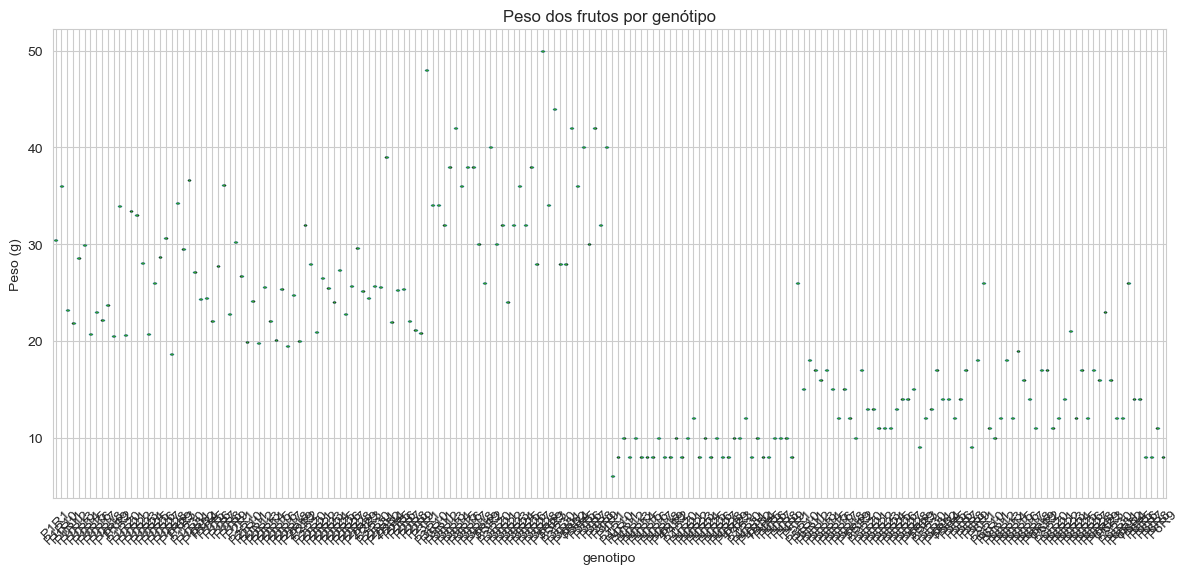


2. RENDIMENTO - % POLPA APROVEITÁVEL
   genotipo  pct_polpa
0      P1R1       17.6
1      P1R2       49.5
2      P1R3       32.9
3      P2R1       46.9
4      P2R2       47.1
5      P2R3       48.0
6      P3R1       31.3
7      P3R2       35.6
8      P3R3       33.8
9      P4R1       60.8
10     P4R2       51.2
11     P4R3       60.7
12     P5R1       43.5
13     P5R2       39.7
14     P5R3       38.6
15     P6R1       35.8
16     P6R2       38.2
17     P6R3       45.5


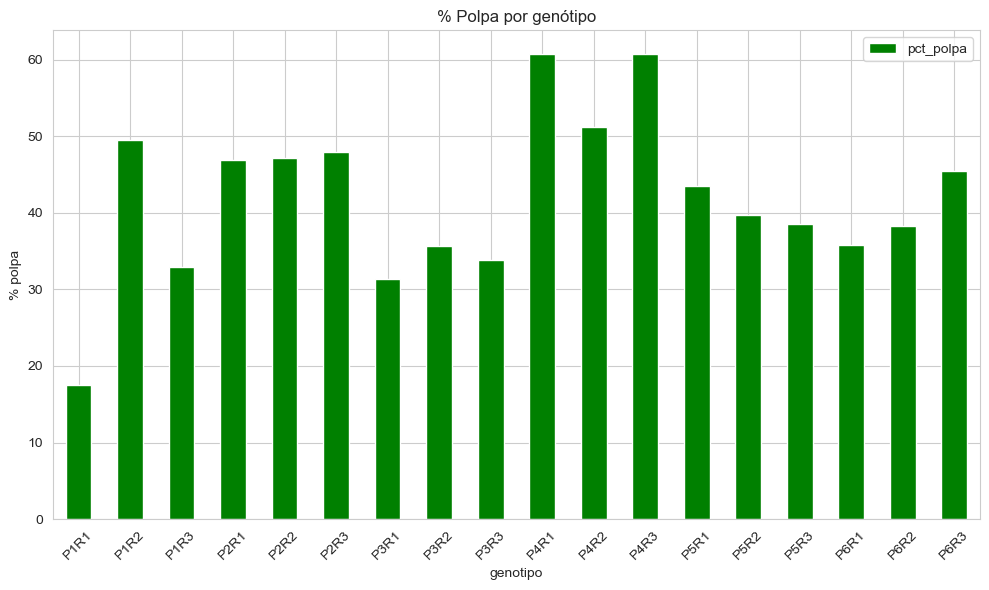

In [2]:
# =====================================================
# ANÁLISE INDIVIDUAL DOS DATASETS
# =====================================================

# 1. AVALIAÇÕES FÍSICAS
seção("1. AVALIAÇÕES FÍSICAS - CARACTERÍSTICAS DOS FRUTOS")
df_cdp = dfs['cdp']
print(f"📏 {len(df_cdp)} frutos medidos")
print(df_cdp.groupby('genotipo')['peso'].agg(['count', 'mean', 'std']).round(1))

# Gráfico rápido
df_cdp.boxplot(column='peso', by='genotipo', figsize=(12,6))
plt.title('Peso dos frutos por genótipo')
plt.suptitle('')
plt.ylabel('Peso (g)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. RENDIMENTO (por genótipo)
seção("2. RENDIMENTO - % POLPA APROVEITÁVEL")
df_rend = dfs['rend']
df_rend['pct_polpa'] = df_rend['peso_da_polpa'] / df_rend['total'] * 100
print(df_rend[['genotipo', 'pct_polpa']].round(1))

df_rend.plot(x='genotipo', y='pct_polpa', kind='bar', color='green')
plt.title('% Polpa por genótipo')
plt.ylabel('% polpa')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# PESO MÉDIO, VOLUME MÉDIO(cm³) e PESO x POLPA


1. PESO MÉDIO POR GENÓTIPO (32 frutos cada)
          mean  std   min   max
gen_base                       
P1        27.2  5.3  18.7  36.7
P2        24.6  4.0  19.5  39.0
P3        35.4  6.2  24.0  50.0
P4         9.0  1.3   6.0  12.0
P5        14.2  3.3   9.0  26.0
P6        14.6  4.7   8.0  26.0


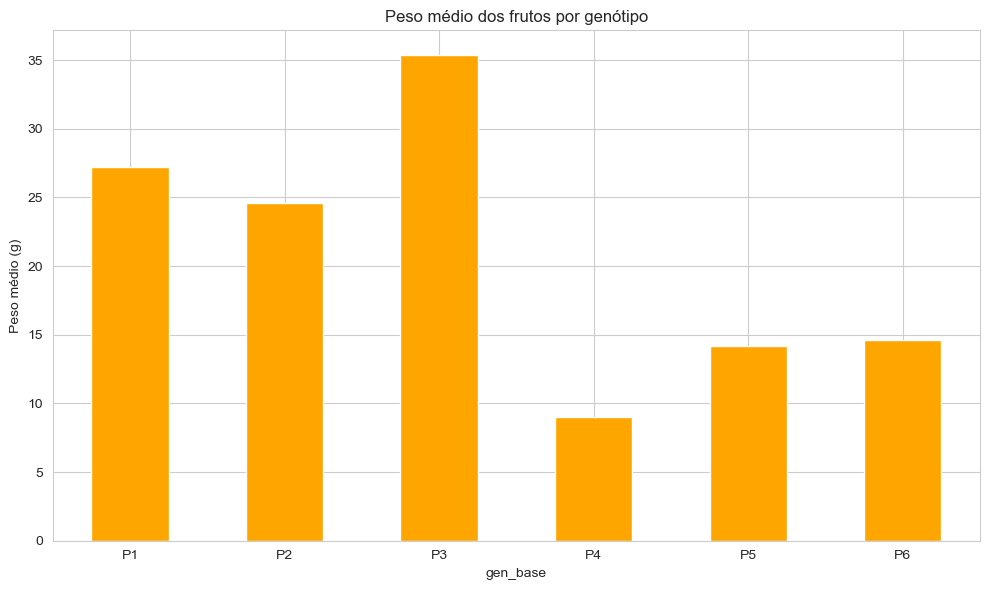


2. VOLUME POR GENÓTIPO (4/3π × comp/2 × diam/2 × diam/2)
Volume médio (cm³):
gen_base
P1    24165.8
P2    23340.6
P3    36966.8
P4     8520.1
P5    13631.9
P6    14884.3
Name: volume, dtype: float64


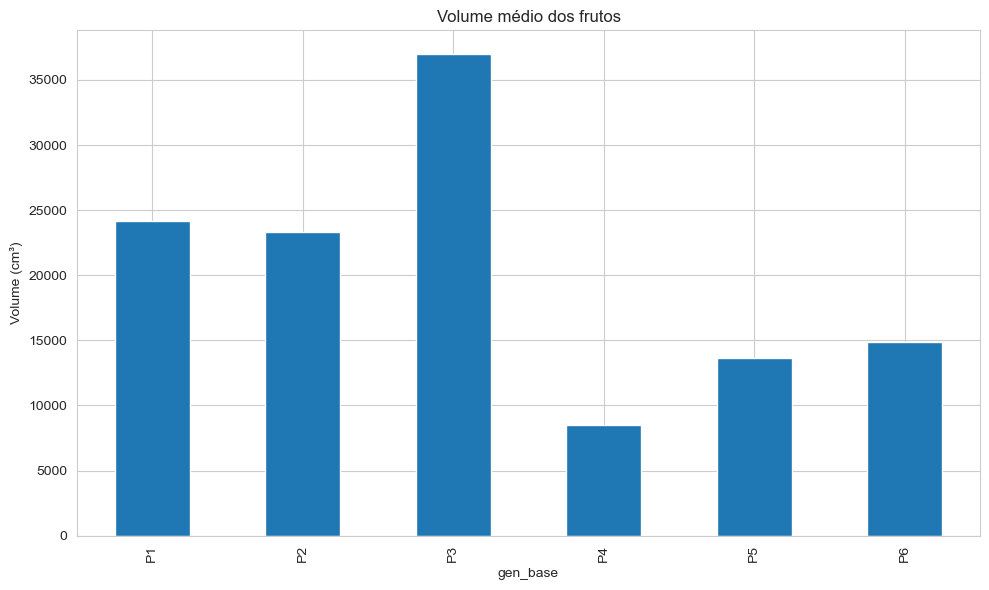


3. GENÓTIPOS 'GRANDES E RENDENTES'
          peso_medio_g  pct_polpa_media
gen_base                               
P1                27.2             33.3
P2                24.6             47.3
P3                35.4             33.6
P4                 9.0             57.6
P5                14.2             40.6
P6                14.6             39.8


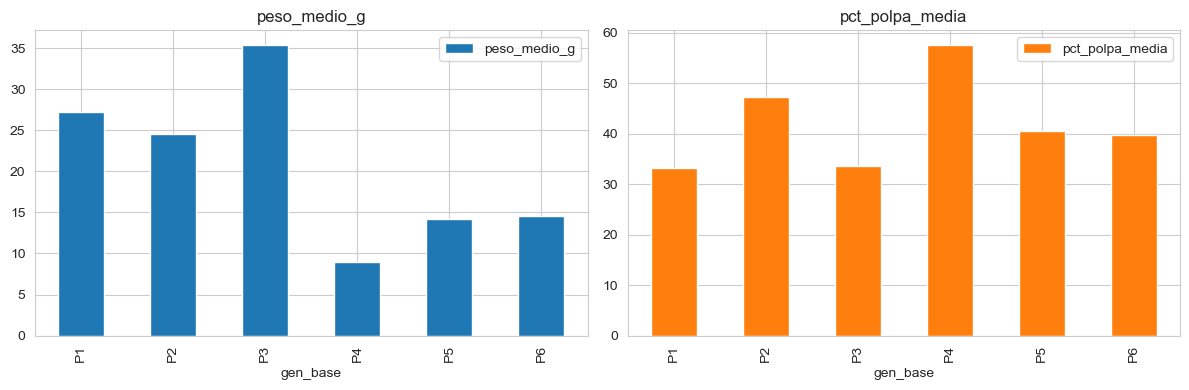


🏆 TOP 3 GENÓTIPOS COMERCIAIS
          peso_medio_g  pct_polpa_media  score_comercial
gen_base                                                
P2                24.6             47.3            128.0
P3                35.4             33.6            126.8
P4                 9.0             57.6            114.0
P1                27.2             33.3            109.9
P5                14.2             40.6             96.1
P6                14.6             39.8             95.5


In [3]:
# =====================================================
# Explorações EXTRAS - AVALIAÇÕES + RENDIMENTO
# =====================================================

# 1️⃣ CORRIGIR AGRUPAMENTO por GENÓTIPO BASE (P1, P2...)
seção("1. PESO MÉDIO POR GENÓTIPO (32 frutos cada)")
df_cdp['gen_base'] = df_cdp['genotipo'].str[:2]  # P1, P2, P3...
peso_medio = df_cdp.groupby('gen_base')['peso'].agg(['mean', 'std', 'min', 'max']).round(1)
print(peso_medio)
peso_medio['mean'].plot(kind='bar', color='orange')
plt.title('Peso médio dos frutos por genótipo')
plt.ylabel('Peso médio (g)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 2️⃣ VOLUME DOS FRUTOS (elipsoide aproximado)
seção("2. VOLUME POR GENÓTIPO (4/3π × comp/2 × diam/2 × diam/2)")
df_cdp['volume'] = (4/3) * 3.1416 * (df_cdp['comprimento']/2) * (df_cdp['diametro']/2)**2
volume_medio = df_cdp.groupby('gen_base')['volume'].mean().round(1)
print("Volume médio (cm³):")
print(volume_medio)
volume_medio.plot(kind='bar')
plt.title('Volume médio dos frutos')
plt.ylabel('Volume (cm³)')
plt.tight_layout()
plt.show()

# 3️⃣ RELAÇÃO POLPA vs PESO (correlação comercial)
seção("3. GENÓTIPOS 'GRANDES E RENDENTES'")
df_rend['gen_base'] = df_rend['genotipo'].str[:2]
rend_medio = df_rend.groupby('gen_base')['pct_polpa'].mean().round(1)
comparacao = pd.merge(peso_medio['mean'], rend_medio, left_index=True, right_index=True)
comparacao.columns = ['peso_medio_g', 'pct_polpa_media']
print(comparacao)
comparacao.plot(kind='bar', subplots=True, layout=(1,2), figsize=(12,4))
plt.tight_layout()
plt.show()

# 4️⃣ TOP 3 genótipos "comerciais" (peso ALTO + polpa ALTA)
seção("🏆 TOP 3 GENÓTIPOS COMERCIAIS")
comparacao['score_comercial'] = (comparacao['peso_medio_g']/50 + comparacao['pct_polpa_media']/60) * 100
print(comparacao.sort_values('score_comercial', ascending=False).round(1))


# DENSIDADE (g/cm³) e POLPA ABSOLUTA(gramas por fruto médio)


1. DENSIDADE - FRUTOS MAIS 'SÓLIDOS'
🏆 Mais densos (g/cm³):
gen_base
P1    1.145
P2    1.068
P4    1.056
P5    1.056
P6    0.987
P3    0.976
Name: densidade, dtype: float64


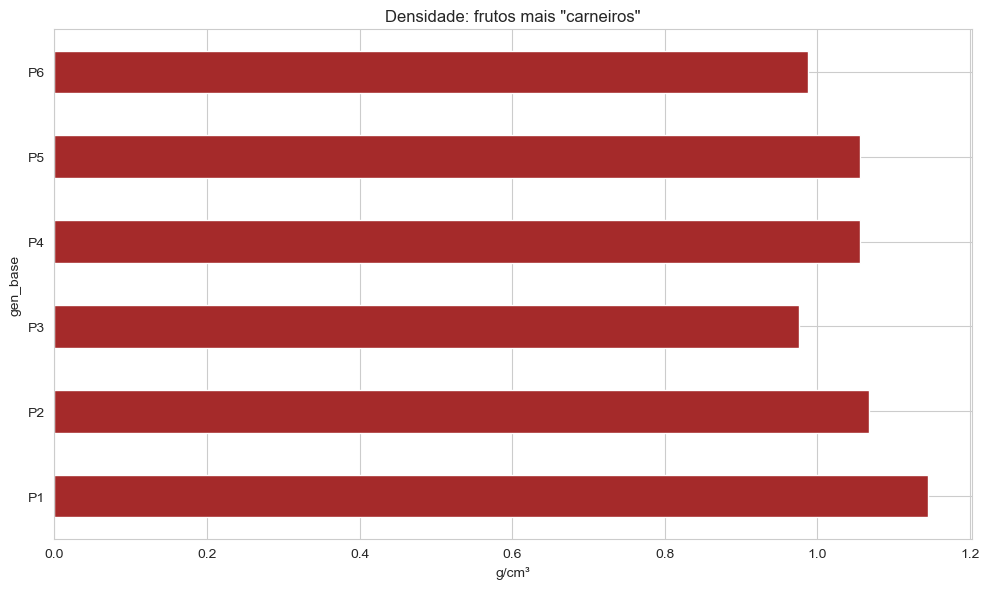


2. POLPA REAL (g por fruto médio)
🏆 Mais polpa absoluta:
gen_base
P2    4.9
P4    3.6
P1    3.3
P3    3.3
P6    2.8
P5    2.4
Name: polpa_medio_fruto, dtype: float64


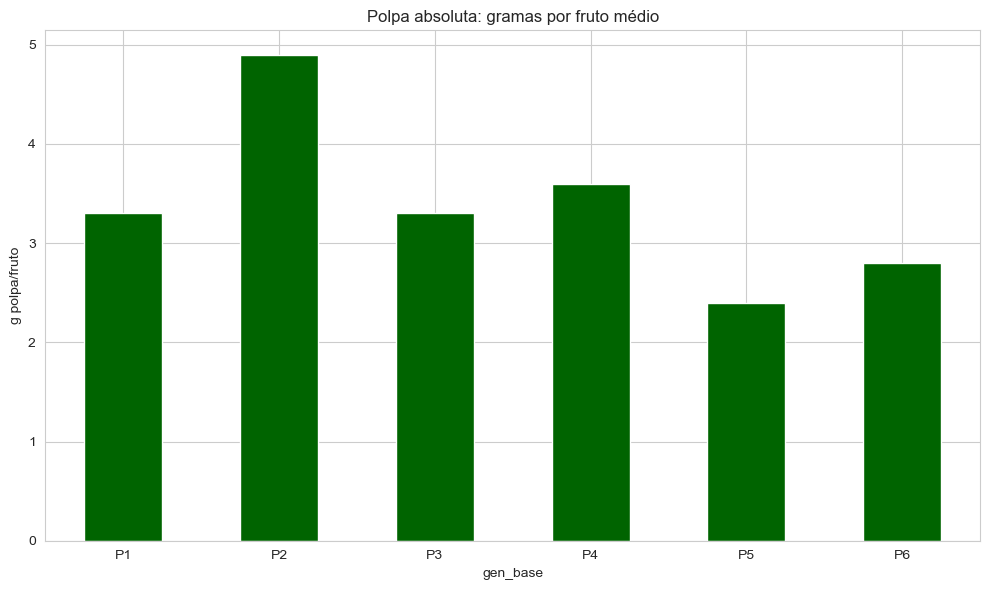


🏆 CLASSIFICAÇÃO FINAL COMERCIAL
          Peso_g  %Polpa  Volume_cm3  Score
gen_base                                   
P2          24.6    47.3     23341.0  128.0
P3          35.4    33.6     36967.0  127.0
P4           9.0    57.6      8520.0  114.0
P1          27.2    33.3     24166.0  110.0
P5          14.2    40.6     13632.0   96.0
P6          14.6    39.8     14884.0   96.0


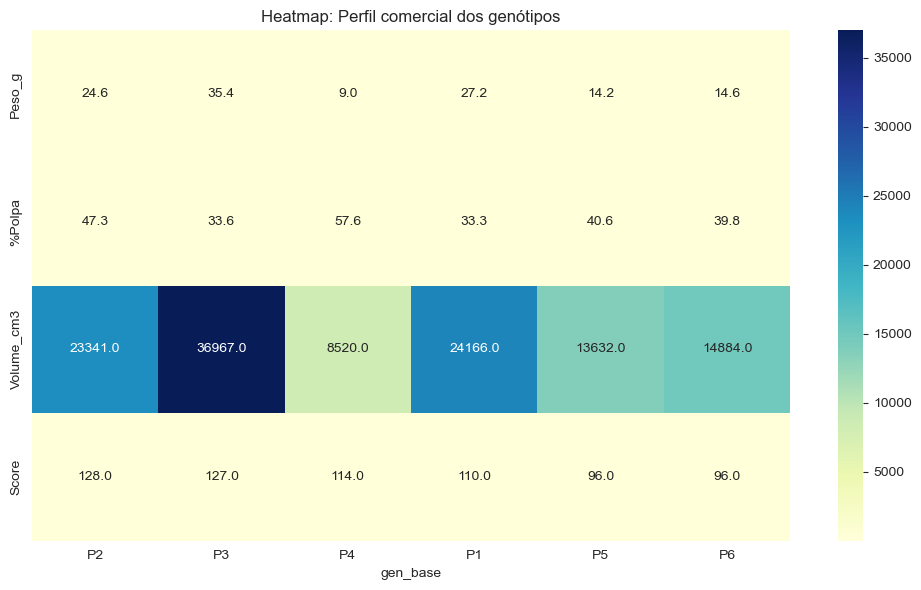

In [4]:
# =====================================================
# FINAL CORRIGIDO: 3 INSIGHTS + GRÁFICO TOP
# =====================================================

# 1️⃣ Densidade (mais carneiro = melhor)
seção("1. DENSIDADE - FRUTOS MAIS 'SÓLIDOS'")
df_cdp['densidade'] = df_cdp['peso'] / (df_cdp['volume']/1000)
dens_medio = df_cdp.groupby('gen_base')['densidade'].mean().round(3)
print("🏆 Mais densos (g/cm³):")
print(dens_medio.sort_values(ascending=False))
dens_medio.plot(kind='barh', color='brown')
plt.title('Densidade: frutos mais "carneiros"')
plt.xlabel('g/cm³')
plt.tight_layout()
plt.show()

# 2️⃣ Polpa ABSOLUTA por fruto médio
seção("2. POLPA REAL (g por fruto médio)")
df_rend['polpa_medio_fruto'] = df_rend['peso_da_polpa'] / 32  # 32 réplicas
polpa_real = df_rend.groupby('gen_base')['polpa_medio_fruto'].mean().round(1)
print("🏆 Mais polpa absoluta:")
print(polpa_real.sort_values(ascending=False))
polpa_real.plot(kind='bar', color='darkgreen')
plt.title('Polpa absoluta: gramas por fruto médio')
plt.ylabel('g polpa/fruto')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 3️⃣ TABELA FINAL + HEATMAP comercial (sem erro!)
seção("🏆 CLASSIFICAÇÃO FINAL COMERCIAL")
final_ranking = pd.DataFrame({
    'Peso_g': peso_medio['mean'].round(1),
    '%Polpa': comparacao['pct_polpa_media'].round(1),
    'Volume_cm3': volume_medio.round(0),
    'Score': comparacao['score_comercial'].round(0)
}).sort_values('Score', ascending=False)
print(final_ranking)
sns.heatmap(final_ranking.T, annot=True, cmap='YlGnBu', fmt='.1f')
plt.title('Heatmap: Perfil comercial dos genótipos')
plt.tight_layout()
plt.show()


# POLPA LIOFILIZADA: VITAMINA C + POLIFENÓIS


🔬 BIOATIVOS: Qual é mais SAUDÁVEL?
🏆 Ranking Vitamina C + Polifenóis:
          vitamina_c  polifenois
gen_base                        
P3             897.0    358931.0
P2             756.0    370415.0
P1             719.0    364444.0
P4             378.0    204816.0
P6             238.0    353411.0
P5             187.0    266102.0


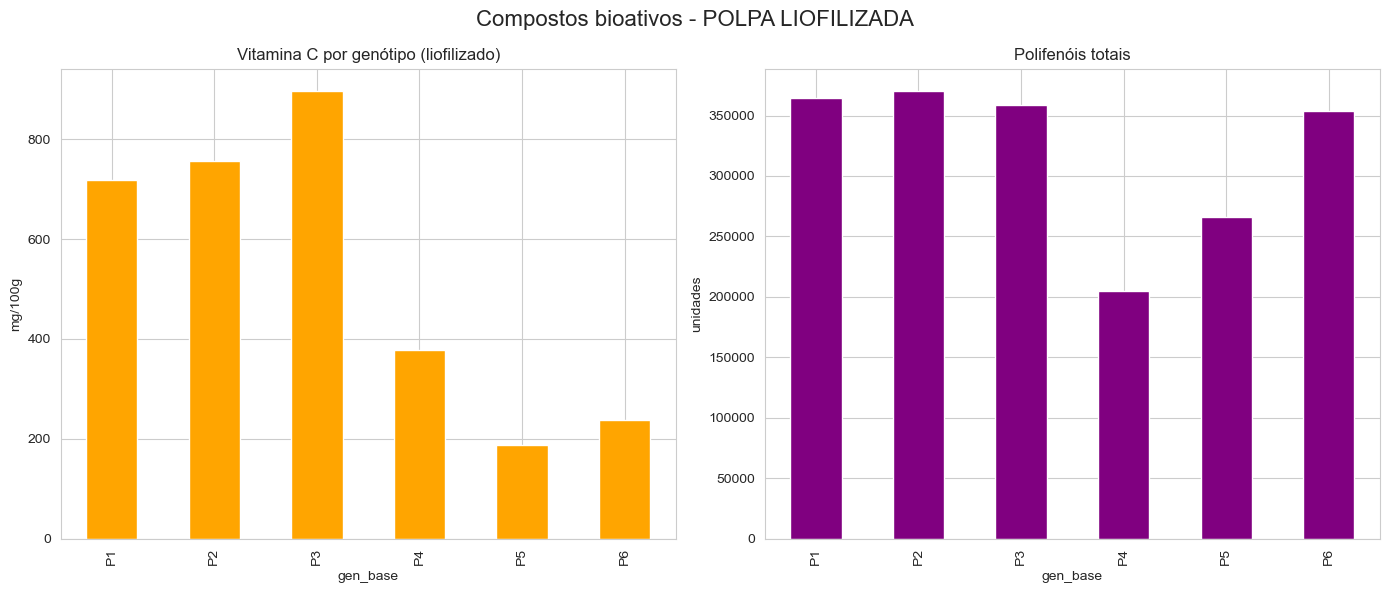

In [6]:
# =====================================================
# BIOATIVOS - Vitamina C + Antioxidantes
# =====================================================
seção("🔬 BIOATIVOS: Qual é mais SAUDÁVEL?")
df_lio = to_float_br(pd.read_csv('afq_amostras_liofilizadas.csv'), 
                     ['clorofila','carotenoide','flavonoide','polifenois','vitamina_c'])
df_lio['gen_base'] = df_lio['genotipo'].str[:2]
bio_medio = df_lio.groupby('gen_base')[['vitamina_c','polifenois']].mean().round(0)
print("🏆 Ranking Vitamina C + Polifenóis:")
print(bio_medio.sort_values('vitamina_c', ascending=False))

# Gráfico duplo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))
bio_medio['vitamina_c'].plot(kind='bar', ax=ax1, color='orange')
ax1.set_title('Vitamina C por genótipo (liofilizado)')
ax1.set_ylabel('mg/100g')

bio_medio['polifenois'].plot(kind='bar', ax=ax2, color='purple')
ax2.set_title('Polifenóis totais')
ax2.set_ylabel('unidades')

plt.suptitle('Compostos bioativos - POLPA LIOFILIZADA', fontsize=16)
plt.tight_layout()
plt.show()


# BIOATIVOS NAS CASCAS

In [7]:
seção("🧪 BIOATIVOS NAS CASCAS")
df_casca_seca = to_float_br(
    pd.read_csv("afq_casca_seca.csv"),
    ["clorofila", "carotenoide", "flavonoide_amarelo", "polifenois"]
)

df_casca_seca["gen_base"] = df_casca_seca["genotipo"].str[:2]

casca_medio = (
    df_casca_seca
    .groupby("gen_base")[["clorofila", "carotenoide", "flavonoide_amarelo", "polifenois"]]
    .mean()
    .round(0)
)

print("Médias de bioativos nas cascas por genótipo:")
print(casca_medio)



🧪 BIOATIVOS NAS CASCAS
Médias de bioativos nas cascas por genótipo:
          clorofila  carotenoide  flavonoide_amarelo  polifenois
gen_base                                                        
P1              2.0        130.0                88.0    268719.0
P2              6.0         75.0               108.0    280131.0
P3              2.0         41.0               101.0    284964.0
P4             15.0        142.0               191.0    148701.0
P5              3.0        445.0               228.0    279156.0
P6              8.0        415.0               242.0    666768.0


# GRÁFICOS POLIFENÓIS

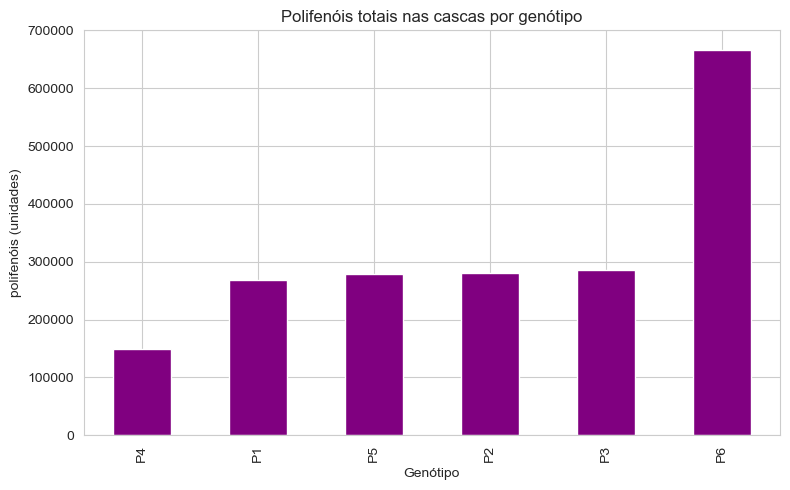

In [8]:
ax = casca_medio[["polifenois"]].sort_values("polifenois").plot(
    kind="bar", figsize=(8,5), legend=False, color="purple"
)
ax.set_title("Polifenóis totais nas cascas por genótipo")
ax.set_ylabel("polifenóis (unidades)")
ax.set_xlabel("Genótipo")
plt.tight_layout()
plt.show()


# COMPARAÇÃO

          polpa_polif  casca_polif
gen_base                          
P1           364444.0     268719.0
P2           370415.0     280131.0
P3           358931.0     284964.0
P4           204816.0     148701.0
P5           266102.0     279156.0
P6           353411.0     666768.0


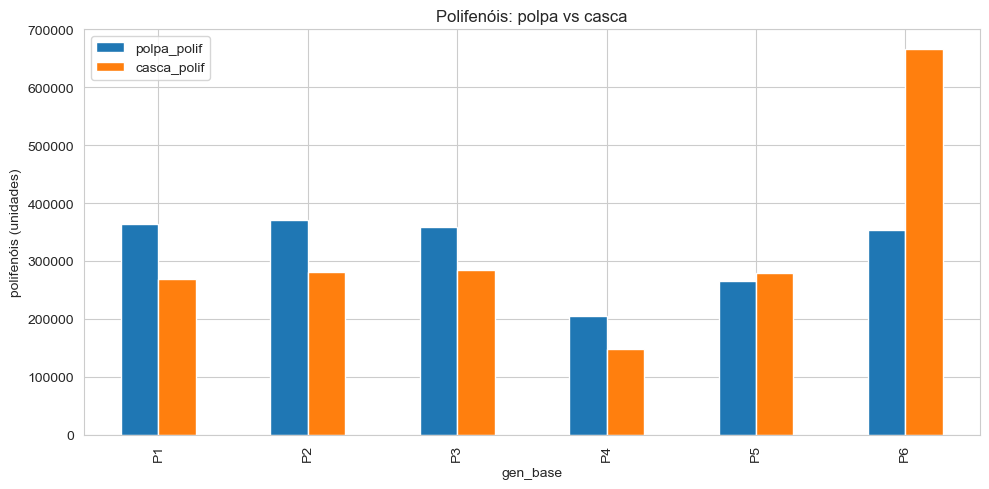

In [9]:
comparacao_polif = pd.DataFrame({
    "polpa_polif": bio_medio["polifenois"],
    "casca_polif": casca_medio["polifenois"],
})

print(comparacao_polif)

comparacao_polif.plot(kind="bar", figsize=(10,5))
plt.title("Polifenóis: polpa vs casca")
plt.ylabel("polifenóis (unidades)")
plt.tight_layout()
plt.show()


# Tabela Final


🧮 TABELA FINAL DE DECISÃO
TABELA FINAL DE DECISÃO (scores 0–1):
          Score_comercial  Score_polpa_bio  Score_casca_bio
gen_base                                                   
P2                  0.667            0.881            0.190
P3                  0.597            0.972            0.166
P4                  0.514            0.161            0.142
P1                  0.364            0.835            0.205
P5                  0.202            0.148            0.542
P6                  0.192            0.402            0.978

TABELA FINAL COM INDICAÇÃO DE USO:
          Score_comercial  Score_polpa_bio  Score_casca_bio  \
gen_base                                                      
P2                  0.667            0.881            0.190   
P3                  0.597            0.972            0.166   
P4                  0.514            0.161            0.142   
P1                  0.364            0.835            0.205   
P5                  0.202            0.14

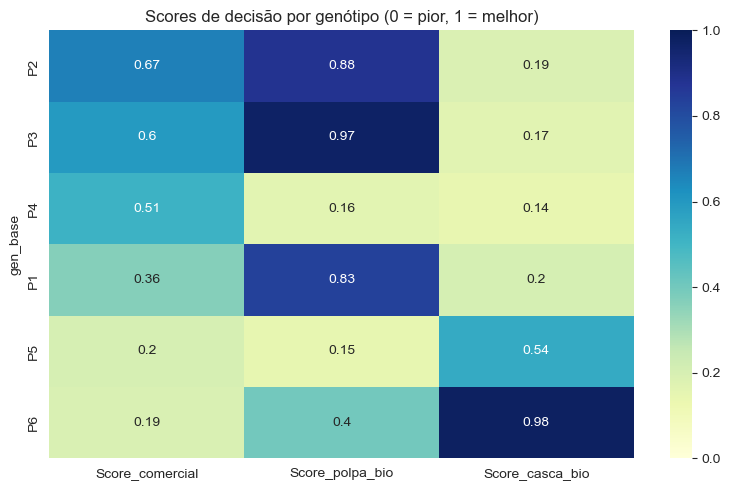

In [10]:
seção("🧮 TABELA FINAL DE DECISÃO")

# -----------------------------
# 1. Base: já temos comparacao, bio_medio, casca_medio
# comparacao: peso_medio_g, pct_polpa_media, score_comercial
# bio_medio: vitamina_c, polifenois (polpa liofilizada)
# casca_medio: clorofila, carotenoide, flavonoide_amarelo, polifenois (casca)
# -----------------------------

# Garantir mesmo índice (P1..P6)
genotipos = sorted(comparacao.index)
bio_m = bio_medio.reindex(genotipos)
casca_m = casca_medio.reindex(genotipos)

# -----------------------------
# 2. Função de normalização 0-1
# -----------------------------
def norm_01(s):
    return (s - s.min()) / (s.max() - s.min())

# -----------------------------
# 3. Score COMERCIAL
#    - peso médio (importância 0.4)
#    - % polpa (0.4)
#    - score_comercial já calculado (0.2)
# -----------------------------
com_peso   = norm_01(comparacao["peso_medio_g"])
com_polpa  = norm_01(comparacao["pct_polpa_media"])
com_score  = norm_01(comparacao["score_comercial"])

score_comercial = (0.4 * com_peso +
                   0.4 * com_polpa +
                   0.2 * com_score)

# -----------------------------
# 4. Score POLPA BIOATIVA
#    - vitamina C (0.6)
#    - polifenóis na polpa (0.4)
# -----------------------------
polpa_vit = norm_01(bio_m["vitamina_c"])
polpa_pol = norm_01(bio_m["polifenois"])

score_polpa_bio = (0.6 * polpa_vit +
                   0.4 * polpa_pol)

# -----------------------------
# 5. Score CASCA BIOATIVA
#    - polifenóis casca (0.6)
#    - carotenoides casca (0.3)
#    - flavonoides casca (0.1)
# -----------------------------
casca_pol  = norm_01(casca_m["polifenois"])
casca_car  = norm_01(casca_m["carotenoide"])
casca_flav = norm_01(casca_m["flavonoide_amarelo"])

score_casca_bio = (0.6 * casca_pol +
                   0.3 * casca_car +
                   0.1 * casca_flav)

# -----------------------------
# 6. Tabela final de decisão
# -----------------------------
tabela_decisao = pd.DataFrame({
    "Score_comercial": score_comercial,
    "Score_polpa_bio": score_polpa_bio,
    "Score_casca_bio": score_casca_bio
}).round(3)

print("TABELA FINAL DE DECISÃO (scores 0–1):")
print(tabela_decisao.sort_values("Score_comercial", ascending=False))

# -----------------------------
# 7. Indicação de uso por genótipo
#    (pega score mais alto para cada tipo de produto)
# -----------------------------
def melhor_para(row):
    col = row.idxmax()
    if col == "Score_comercial":
        return "produto in natura / polpa básica"
    elif col == "Score_polpa_bio":
        return "polpa/néctar funcional"
    else:
        return "aproveitamento de casca"

tabela_decisao["Indicação_principal"] = tabela_decisao.apply(melhor_para, axis=1)

print("\nTABELA FINAL COM INDICAÇÃO DE USO:")
print(tabela_decisao.sort_values("Score_comercial", ascending=False))

# Opcional: visualização em heatmap
plt.figure(figsize=(8,5))
sns.heatmap(tabela_decisao[["Score_comercial","Score_polpa_bio","Score_casca_bio"]]
            .sort_values("Score_comercial", ascending=False),
            annot=True, cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Scores de decisão por genótipo (0 = pior, 1 = melhor)")
plt.tight_layout()
plt.show()


# Comparação polpa liofilizada x casca


📊 Comparação de polifenóis: polpa liofilizada vs casca
Polifenóis totais: polpa vs casca
          polpa_polif  casca_polif  casca_polpa_ratio
gen_base                                             
P1           364444.0     268719.0               0.74
P2           370415.0     280131.0               0.76
P3           358931.0     284964.0               0.79
P4           204816.0     148701.0               0.73
P5           266102.0     279156.0               1.05
P6           353411.0     666768.0               1.89


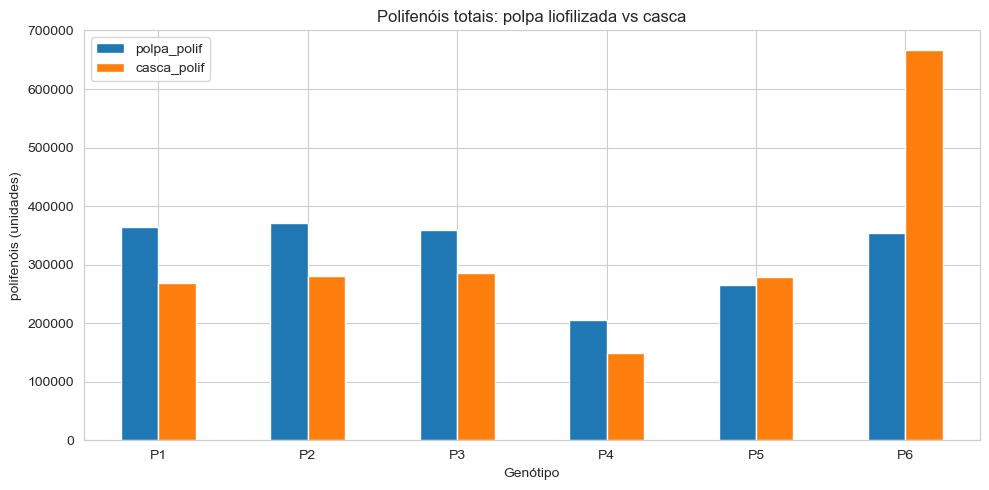

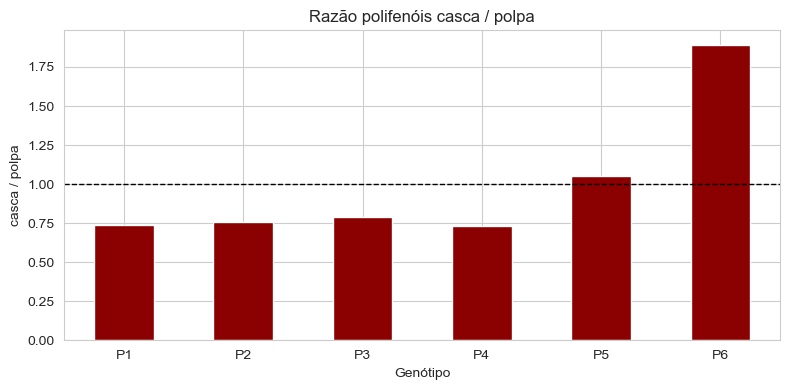

In [11]:
seção("📊 Comparação de polifenóis: polpa liofilizada vs casca")

# 1. Garantir que os DataFrames estão alinhados pelo mesmo índice (P1..P6)
genotipos = sorted(bio_medio.index)  # ou sorted(casca_medio.index)
polpa_polif  = bio_medio.reindex(genotipos)["polifenois"]
casca_polif  = casca_medio.reindex(genotipos)["polifenois"]

# 2. Montar tabela de comparação
comp_polif = pd.DataFrame({
    "polpa_polif": polpa_polif,
    "casca_polif": casca_polif
})
comp_polif["casca_polpa_ratio"] = (comp_polif["casca_polif"] /
                                   comp_polif["polpa_polif"]).round(2)

print("Polifenóis totais: polpa vs casca")
print(comp_polif)

# 3. Gráfico comparando polpa e casca
ax = comp_polif[["polpa_polif", "casca_polif"]].plot(
    kind="bar", figsize=(10, 5)
)
ax.set_title("Polifenóis totais: polpa liofilizada vs casca")
ax.set_ylabel("polifenóis (unidades)")
ax.set_xlabel("Genótipo")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. Gráfico da razão casca/polpa
ax2 = comp_polif["casca_polpa_ratio"].plot(
    kind="bar", color="darkred", figsize=(8, 4)
)
ax2.axhline(1, color="black", linestyle="--", linewidth=1)
ax2.set_title("Razão polifenóis casca / polpa")
ax2.set_ylabel("casca / polpa")
ax2.set_xlabel("Genótipo")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# Comparação polifenóis: polpa LÍQUIDA vs casca


💧 x 🍊 Comparação polifenóis: polpa LÍQUIDA vs casca
Polifenóis totais: polpa LÍQUIDA vs casca
          polpa_liquida_polif  casca_polif  casca_polpaL_ratio
gen_base                                                      
P1                     8939.0     268719.0               30.06
P2                    10060.0     280131.0               27.85
P3                     6900.0     284964.0               41.30
P4                    10021.0     148701.0               14.84
P5                    13143.0     279156.0               21.24
P6                    16227.0     666768.0               41.09


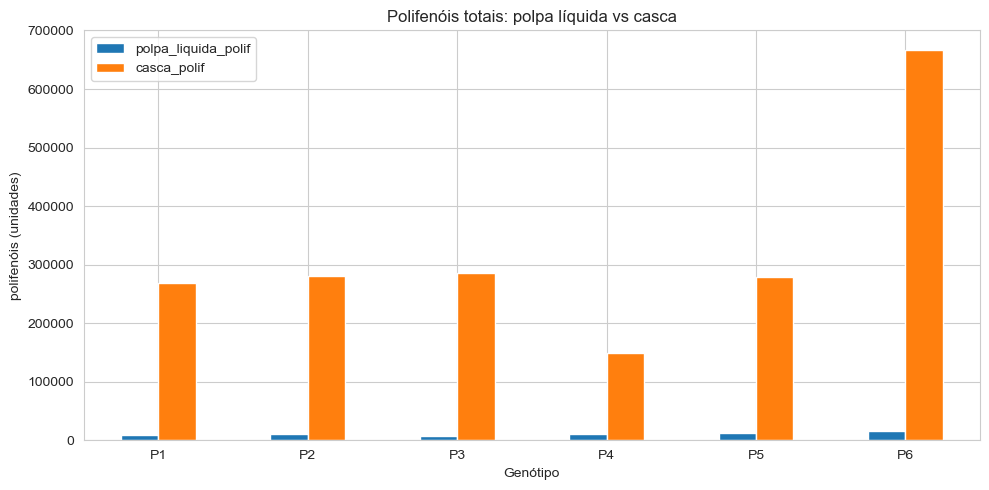

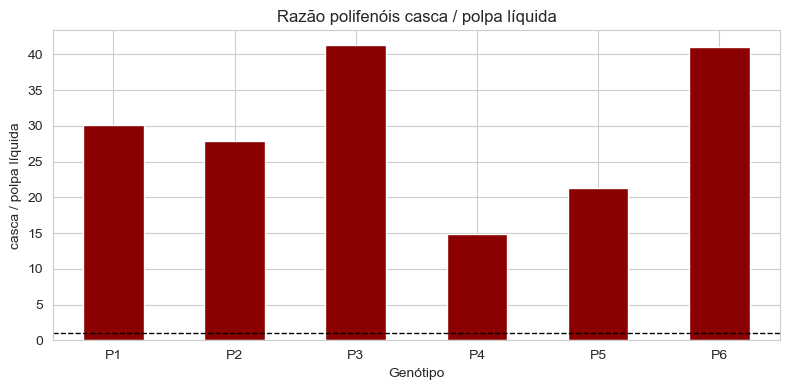

In [12]:
seção("💧 x 🍊 Comparação polifenóis: polpa LÍQUIDA vs casca")

# 1. Carregar e preparar polpa líquida
df_liq = to_float_br(
    pd.read_csv("afq_amostras_liquidas.csv"),
    ["umidade", "açucares_totais", "acidez_titulavel", "ph",
     "solidos_soluveis", "ss_at", "clorofila", "carotenoide",
     "flavonoide_amarelo", "polifenois", "vitamina_c"]
)
df_liq["gen_base"] = df_liq["genotipo"].str[:2]

# média de polifenóis na polpa líquida por genótipo
liq_polif = (
    df_liq
    .groupby("gen_base")["polifenois"]
    .mean()
    .round(0)
)

# 2. Casca (se ainda não tiver o df_casca pronto)
df_casca_seca = to_float_br(
    pd.read_csv("afq_casca_seca.csv"),
    ["clorofila", "carotenoide", "flavonoide", "polifenois"]
)
df_casca_seca["gen_base"] = df_casca_seca["genotipo"].str[:2]
casca_polif = (
    df_casca_seca
    .groupby("gen_base")["polifenois"]
    .mean()
    .round(0)
)

# 3. Juntar polifenóis polpa LÍQUIDA x casca
genotipos = sorted(set(liq_polif.index) & set(casca_polif.index))

comp_liq_casca = pd.DataFrame({
    "polpa_liquida_polif": liq_polif.reindex(genotipos),
    "casca_polif": casca_polif.reindex(genotipos)
})

comp_liq_casca["casca_polpaL_ratio"] = (
    comp_liq_casca["casca_polif"] /
    comp_liq_casca["polpa_liquida_polif"]
).round(2)

print("Polifenóis totais: polpa LÍQUIDA vs casca")
print(comp_liq_casca)

# 4. Gráfico comparando
ax = comp_liq_casca[["polpa_liquida_polif", "casca_polif"]].plot(
    kind="bar", figsize=(10, 5)
)
ax.set_title("Polifenóis totais: polpa líquida vs casca")
ax.set_ylabel("polifenóis (unidades)")
ax.set_xlabel("Genótipo")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. Razão casca / polpa líquida
ax2 = comp_liq_casca["casca_polpaL_ratio"].plot(
    kind="bar", color="darkred", figsize=(8, 4)
)
ax2.axhline(1, color="black", linestyle="--", linewidth=1)
ax2.set_title("Razão polifenóis casca / polpa líquida")
ax2.set_ylabel("casca / polpa líquida")
ax2.set_xlabel("Genótipo")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
